# Chapter 4 — Training Linear Models

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [22]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.linear_model import (LinearRegression, SGDRegressor, Ridge,
                                   Lasso, ElasticNet, LogisticRegression)
from sklearn.preprocessing import (PolynomialFeatures, StandardScaler,
                                    add_dummy_feature)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.datasets import load_iris, make_regression
from sklearn.metrics import root_mean_squared_error

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Resumen: Modelo de Regresión Lineal

## 1. Modelo lineal simple (una característica)

La satisfacción de vida se modela como una función lineal del PIB per cápita:

$$
\text{life\_satisfaction} = \theta_0 + \theta_1 \times \text{GDP\_per\_capita}
$$

Donde $\theta_0$ y $\theta_1$ son los **parámetros del modelo**.

## 2. Modelo de regresión lineal general (múltiples características)

La predicción $\hat{y}$ se calcula como una suma ponderada de las características de entrada más un sesgo (intercepto):

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

- $\hat{y}$ : valor predicho.
- $n$ : número de características.
- $x_i$ : valor de la $i$-ésima característica.
- $\theta_j$ : $j$-ésimo parámetro del modelo ($\theta_0$ es el sesgo, $\theta_1 \dots \theta_n$ son los pesos).

## 3. Forma vectorizada

El modelo puede escribirse de manera compacta usando el producto punto:

$$
\hat{y} = h_\theta(\mathbf{x}) = \boldsymbol{\theta} \cdot \mathbf{x}
$$

- $h_\theta$ : función de hipótesis parametrizada por $\boldsymbol{\theta}$.
- $\boldsymbol{\theta}$ : vector de parámetros $[\theta_0, \theta_1, \dots, \theta_n]$.
- $\mathbf{x}$ : vector de características $[x_0, x_1, \dots, x_n]$, **con $x_0 = 1$ siempre**.
- $\boldsymbol{\theta} \cdot \mathbf{x}$ : producto punto igual a $\theta_0 x_0 + \theta_1 x_1 + \cdots + \theta_n x_n$.

La función a minimizar MSE (Mean Squared Error) se define como:
$$
J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(\mathbf{x}^{(i)}) - y^{(i)})^2
$$

## The Normal Equation

La solución analítica para encontrar los parámetros $\boldsymbol{\theta}$ que minimizan la función de costo MSE es dada por la **Ecuación Normal**:
$$
\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

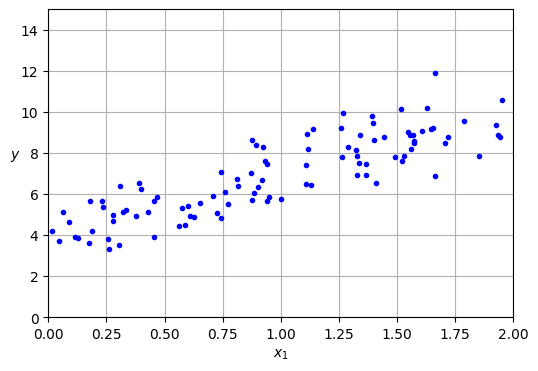

In [23]:
import numpy as np

rng = np.random.default_rng(42)
m = 100
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + ruido gaussiano

# extra code – generates Figure 4–1

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [24]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # agrega una columna de 1s para el término de sesgo
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.94869973],
       [3.03831479]])

In [25]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.94869973],
       [10.02532931]])

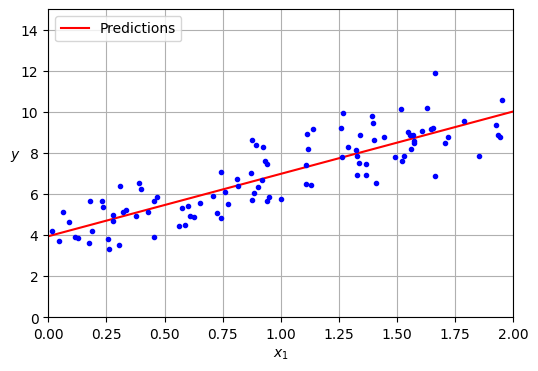

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)
lr.intercept_, lr.coef_

(array([3.94869973]), array([[3.03831479]]))

In [29]:
lr.predict(X_new)

array([[ 3.94869973],
       [10.02532931]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [30]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.94869973],
       [3.03831479]])

This function computes $\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^{+}$ is the _pseudoinverse_ of $\mathbf{X}$ (specifically the Moore-Penrose inverse). You can use `np.linalg.pinv()` to compute the pseudoinverse directly:

In [31]:
np.linalg.pinv(X_b) @ y

array([[3.94869973],
       [3.03831479]])

# Gradient Descent
## Batch Gradient Descent

Para cada parámetro $\theta_j$ se necesita la **derivada parcial** de la función de costo (MSE) respecto a $\theta_j$:

$$
\frac{\partial}{\partial \theta_j} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^\top \mathbf{x}^{(i)} - y^{(i)} \right) x_j^{(i)}
\qquad (4\text{-}6)
$$

El **vector gradiente** agrupa todas las derivadas parciales:

$$
\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = 
\begin{bmatrix}
\frac{\partial}{\partial \theta_0} \text{MSE}(\boldsymbol{\theta}) \\
\frac{\partial}{\partial \theta_1} \text{MSE}(\boldsymbol{\theta}) \\
\vdots \\
\frac{\partial}{\partial \theta_n} \text{MSE}(\boldsymbol{\theta})
\end{bmatrix}
= \frac{2}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
\qquad (4\text{-}7)
$$

- La derivada parcial mide el cambio de la función al modificar ligeramente $\theta_j$.
- El gradiente apunta en la dirección de máximo crecimiento; se usa con signo contrario para descender.